<a href="https://colab.research.google.com/github/ahirjaydeep/AI-Vision-Classifier/blob/main/Vision_Master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐾 AI Vision Classifier: Animals-10 Dataset
**Project Lead / ML Architecture:** Jaydeep Ahir  
**Data Engineering / Pipeline:** Jihan Gajjar  

> **Author's Note on AI Assistance:** The machine learning architecture, data engineering pipeline, and core code execution in this project are our original collaborative work. To ensure clear, professional documentation, the explanatory markdown text, structural formatting, and inline code comments were drafted with the assistance of an AI language model.

**Objective:** Build a robust image classification model capable of distinguishing between 10 animal species using transfer learning (MobileNetV2) and a 30,000 image dataset.

## Phase 1: Data Acquisition & Preprocessing (By Jihan Gajjar)
Downloading the dataset and establishing the global class mappings.

In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np

# Download data
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = os.path.join(path, "raw-img")

# Global Class Mapping
class_names_it = sorted(os.listdir(data_dir))
class_names_en = ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
global_class_map = dict(zip(class_names_it, class_names_en))

print("\nDataset ready. Classes mapped.")

Using Colab cache for faster access to the 'animals10' dataset.

Dataset ready. Classes mapped.


### 1.2 Building the Augmented Data Pipeline
Applying real-time transformations (rotation, zoom, flips) to the training data to prevent model overfitting.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Validation Generator (Strictly scaling, NO augmentation, shuffle=False for accurate evaluation later)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Create the specific generators
train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_gen = val_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False # Crucial for the Confusion Matrix in Phase 3
)

Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.


## Phase 2: Model Architecture & Training (By Jaydeep Ahir)
Building the neural network using MobileNetV2 for feature extraction, followed by a custom dense classification head. *Note: This architecture directly utilizes the augmented `train_gen` pipeline built in Phase 1.*

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# 1. Load Pretrained Base
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze base for Phase 1 training

# 2. Architect Custom Head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.1 Phase 1 Training (Frozen Base) & Metric Visualization

Epoch 1/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 371s 566ms/step - accuracy: 0.9097 - loss: 0.2870 - val_accuracy: 0.9474 - val_loss: 0.1672
Epoch 2/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 264s 403ms/step - accuracy: 0.9261 - loss: 0.2314 - val_accuracy: 0.9494 - val_loss: 0.1598
Epoch 3/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 265s 404ms/step - accuracy: 0.9309 - loss: 0.2131 - val_accuracy: 0.9524 - val_loss: 0.1508
Epoch 4/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 264s 403ms/step - accuracy: 0.9340 - loss: 0.2020 - val_accuracy: 0.9507 - val_loss: 0.1563
Epoch 5/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 263s 402ms/step - accuracy: 0.9393 - loss: 0.1868 - val_accuracy: 0.9560 - val_loss: 0.1506
Epoch 6/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 264s 403ms/step - accuracy: 0.9416 - loss: 0.1839 - val_accuracy: 0.9507 - val_loss: 0.1760
Epoch 7/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 265s 404ms/step - accuracy: 0.9436 - loss: 0.1757 - val_accuracy: 0.9539 - val_loss: 0.1444
Epoch 8/10
655/655 ━━━━━━━━━━━━━━━━━━━━ 262s 399ms/step - accuracy: 0.9443 -

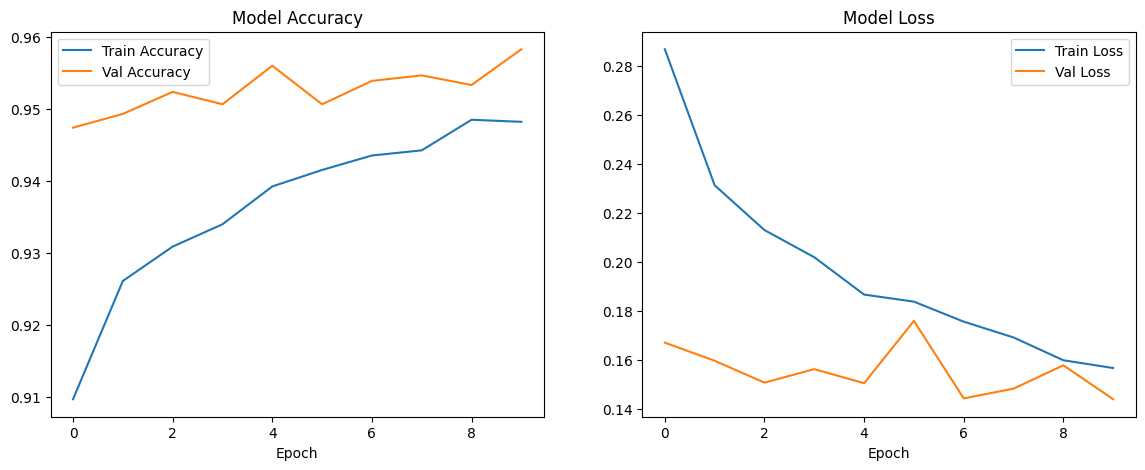

In [ ]:
# Train the model using the pipeline from Phase 1
history = model.fit(train_gen, validation_data=val_gen, epochs=10, verbose=1)

# Plotting Metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

### 2.2 Phase 2 Fine-Tuning
Unfreezing the top 50 layers to adapt the ImageNet weights specifically to our animal dataset.

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_fine = model.fit(train_gen, validation_data=val_gen, epochs=5, verbose=1)

model.save("Zenity_Vision_Classifier.h5")
print("Model optimized and saved.")

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 310s 439ms/step - accuracy: 0.9113 - loss: 0.2786 - val_accuracy: 0.9566 - val_loss: 0.1516
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 268s 410ms/step - accuracy: 0.9383 - loss: 0.1902 - val_accuracy: 0.9580 - val_loss: 0.1451
Epoch 3/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 268s 409ms/step - accuracy: 0.9443 - loss: 0.1709 - val_accuracy: 0.9604 - val_loss: 0.1402
Epoch 4/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 268s 409ms/step - accuracy: 0.9478 - loss: 0.1577 - val_accuracy: 0.9597 - val_loss: 0.1312
Epoch 5/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 268s 410ms/step - accuracy: 0.9549 - loss: 0.1423 - val_accuracy: 0.9627 - val_loss: 0.1320


Model optimized and saved.


## Phase 3: Evaluation & Testing
Generating a Confusion Matrix to analyze specific class misclassifications, and testing the model via an inference function.

Generating predictions for Confusion Matrix...
164/164 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step


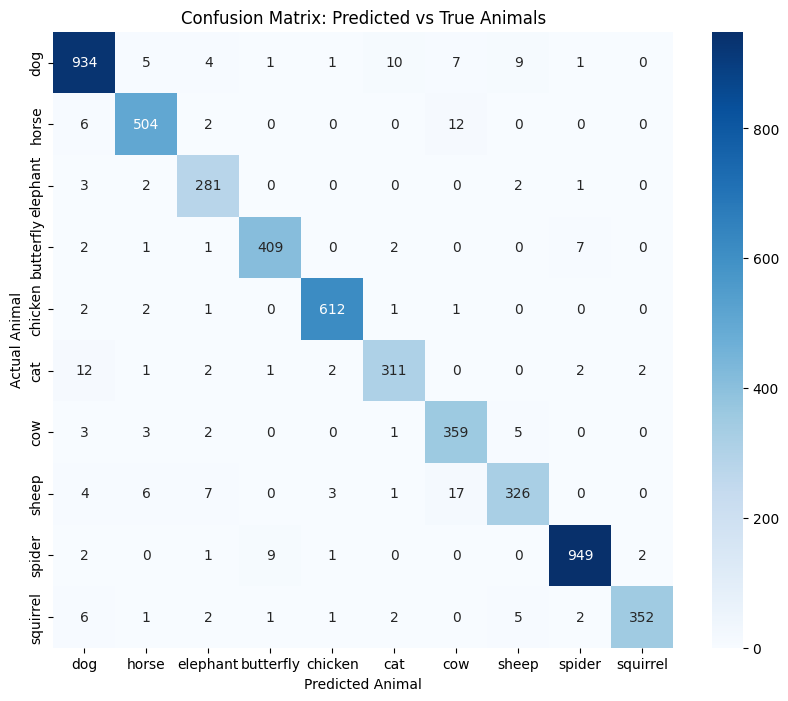


Classification Report:

              precision    recall  f1-score   support

         dog       0.96      0.96      0.96       972
       horse       0.96      0.96      0.96       524
    elephant       0.93      0.97      0.95       289
   butterfly       0.97      0.97      0.97       422
     chicken       0.99      0.99      0.99       619
         cat       0.95      0.93      0.94       333
         cow       0.91      0.96      0.93       373
       sheep       0.94      0.90      0.92       364
      spider       0.99      0.98      0.99       964
    squirrel       0.99      0.95      0.97       372

    accuracy                           0.96      5232
   macro avg       0.96      0.96      0.96      5232
weighted avg       0.96      0.96      0.96      5232



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Generating predictions for Confusion Matrix...")
# Predict on the validation set
Y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(Y_pred, axis=1)

# Get true labels
true_classes = val_gen.classes

# Generate Matrix
cm = confusion_matrix(true_classes, y_pred_classes)

# Plot Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_en,
            yticklabels=class_names_en)
plt.title('Confusion Matrix: Predicted vs True Animals')
plt.ylabel('Actual Animal')
plt.xlabel('Predicted Animal')
plt.show()

# Print text report
print("\nClassification Report:\n")
print(classification_report(true_classes, y_pred_classes, target_names=class_names_en))

📂 Click 'Choose Files' to upload one or more images from your computer.
💡 Tip: You can select multiple images at once to test a whole batch!


Saving download (1).jpeg to download (1).jpeg

Processing: download (1).jpeg...


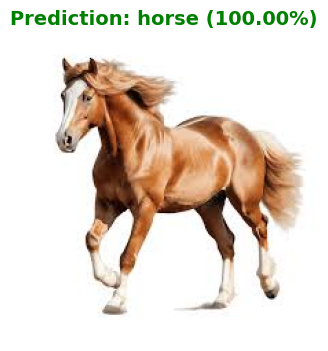

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import io

def predict_uploaded_images():
    print("📂 Click 'Choose Files' to upload one or more images from your computer.")
    print("💡 Tip: You can select multiple images at once to test a whole batch!")

    # This generates the interactive upload button in Colab
    uploaded = files.upload()

    # Loop through every file the user uploaded
    for filename in uploaded.keys():
        print(f"\nProcessing: {filename}...")

        # Convert the uploaded raw bytes into an image
        img_data = uploaded[filename]
        img = image.load_img(io.BytesIO(img_data), target_size=(224, 224))

        # Preprocess the image for MobileNetV2
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        # Make the prediction
        predictions = model.predict(img_array, verbose=0)
        predicted_index = np.argmax(predictions)

        # Map back to English label
        italian_label = list(train_gen.class_indices.keys())[predicted_index]
        english_label = global_class_map[italian_label]
        confidence = predictions[0][predicted_index] * 100

        # Display the image with the prediction
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')

        # Color code the title: Green for high confidence (>80%), Orange for lower
        title_color = 'green' if confidence > 80 else 'darkorange'
        plt.title(f"Prediction: {english_label} ({confidence:.2f}%)",
                  fontsize=14, fontweight='bold', color=title_color)
        plt.show()

# Run the interactive tool
predict_uploaded_images()